In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [15]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int
    
    sr : float
    boundary_per_balls : int
    boundary_percent : int
    
    summary : str

In [16]:
def batsman_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100
    
    return {'sr' : sr}

In [17]:
def boundary_per_balls(state: BatsmanState):
    bpb = (state['balls']//(state['fours'] + state['sixes']))
    
    return {'boundary_per_balls' : bpb}

In [18]:
def boundary_percent(state: BatsmanState):
    b_per_c = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100
    
    return {'boundary_percent' : b_per_c}

In [19]:
def summary(state: BatsmanState):
    summary = f"""
    Batsman Strike Rate - {state['sr']}
    Batsman Boundary per balls - {state['boundary_per_balls']}
    batsman Boundary Percentage - {state['boundary_percent']}
    """

In [20]:
state = StateGraph(BatsmanState)

state.add_node('batsman_strikeRate', batsman_sr)
state.add_node('boundary_per_balls', boundary_per_balls)
state.add_node('boundary_percent', boundary_percent)
state.add_node('summary', summary)

state.add_edge(START, 'batsman_strikeRate')
state.add_edge(START, 'boundary_per_balls')
state.add_edge(START, 'boundary_percent')
state.add_edge('batsman_strikeRate', 'summary')
state.add_edge('boundary_per_balls', 'summary')
state.add_edge('boundary_percent', 'summary')
state.add_edge('summary', END)

workflow = state.compile()


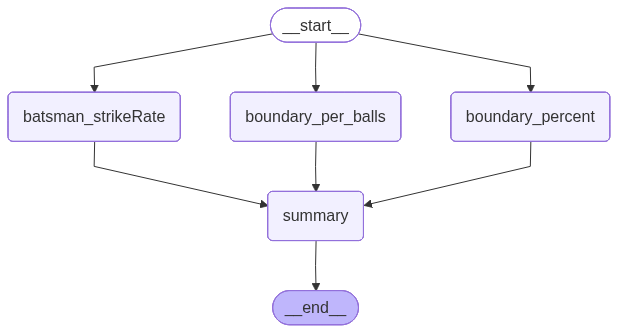

In [21]:
workflow

In [22]:
initial_state = {'runs': 100, 'balls': 50, 'fours': 5, 'sixes': 7}

final_flow = workflow.invoke(initial_state)

In [23]:
print(final_flow)

{'runs': 100, 'balls': 50, 'fours': 5, 'sixes': 7, 'sr': 200.0, 'boundary_per_balls': 4, 'boundary_percent': 62.0}
